# Statistical Significance Testing -- WELFake Fake News Detection

This notebook applies McNemar's statistical significance
test to confirm that performance differences between
models are not due to random chance.

McNemar's test is appropriate here because all models
are evaluated on the same held-out test set. Predictions
are therefore paired (dependent) -- both models see the
same articles. A standard t-test would be incorrect
because it assumes independence between samples.

The null hypothesis for each pair is:
"Both models make the same proportion of errors."
A p-value below 0.05 rejects the null hypothesis,
confirming the performance difference is statistically
significant at the 95% confidence level.

Three pairs are tested:
Pair 1: LinearSVC vs BiLSTM
        Did the neural baseline significantly beat
        the best classical model?
Pair 2: BiLSTM vs Full Hybrid
        Did the hybrid model significantly beat
        the neural baseline?
Pair 3: LinearSVC vs No-Linguistic variant
        Did our best overall model significantly beat
        the best classical model?

This notebook runs on Google Colab CPU. No GPU needed.

## Section 1 -- Setup and Imports

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import sys
import re
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score, accuracy_score
from scipy.stats import chi2_contingency
import joblib

BASE          = '/content/drive/MyDrive/MSU Semester 4/Applied ML/Project'
PROCESSED_DIR = BASE + '/processed/'
MODELS_DIR    = BASE + '/models/'
FIGURES_DIR   = BASE + '/figures/ablation/'
RESULTS_DIR   = BASE + '/results/'

sys.path.append(BASE + '/src/')

from models   import get_device
from utils    import set_seed, print_section

set_seed(42)
device = torch.device('cpu')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

ALPHA = 0.05

print("Setup complete. Running on Colab CPU.")
print(f"Significance threshold: alpha = {ALPHA}")

Mounted at /content/drive
Random seed set to 42
Setup complete. Running on Colab CPU.
Significance threshold: alpha = 0.05


## Section 2 -- Load Test Set

The same held-out test set used in all previous notebooks
is loaded here. Using the exact same articles ensures
all model predictions are directly comparable.

In [2]:
print_section("Loading Test Set")

test_df  = pd.read_csv(
    os.path.join(PROCESSED_DIR, 'test_clean.csv'))
train_df = pd.read_csv(
    os.path.join(PROCESSED_DIR, 'train_clean.csv'))
val_df   = pd.read_csv(
    os.path.join(PROCESSED_DIR, 'val_clean.csv'))

X_test_text  = test_df['content'].fillna('').tolist()
X_train_text = train_df['content'].fillna('').tolist()
y_test       = test_df['label'].values

print(f"Test set size  : {len(y_test):,} articles")
print(f"Fake (label=0) : {(y_test==0).sum():,}")
print(f"Real (label=1) : {(y_test==1).sum():,}")

Loading Test Set
Test set size  : 9,399 articles
Fake (label=0) : 5,193
Real (label=1) : 4,206


## Section 3 -- Generate Predictions from All Models

Predictions are generated fresh by loading each saved
model and running inference on the test set. This ensures
predictions are reproducible and not dependent on any
runtime state from previous notebooks.

Four models are loaded:
1. LinearSVC -- from notebook 03 (classical baseline)
2. BiLSTM    -- from notebook 04 (neural baseline)
3. Full Hybrid   -- from notebook 07
4. No-Linguistic -- from notebook 08 (best model)

In [3]:
print_section("Generating Predictions -- LinearSVC")

tfidf_vec = joblib.load(MODELS_DIR + 'tfidf_vectorizer.joblib')
X_test_tfidf_nb03 = tfidf_vec.transform(X_test_text)

svm_model = joblib.load(MODELS_DIR + 'model_svm.joblib')
preds_svm = svm_model.predict(X_test_tfidf_nb03)
svm_f1    = f1_score(y_test, preds_svm, average='macro')

print(f"LinearSVC F1 Macro : {svm_f1:.4f}")
print(f"Predictions shape  : {preds_svm.shape}")

Generating Predictions -- LinearSVC
LinearSVC F1 Macro : 0.9720
Predictions shape  : (9399,)


### BiLSTM Predictions

In [4]:
print_section("Generating Predictions -- BiLSTM")

# Load tokenizer and encode sequences
# Must use identical tokenization to notebook 04
word2idx   = joblib.load(
    os.path.join(MODELS_DIR, 'tokenizer.joblib'))
VOCAB_SIZE = len(word2idx)
MAX_LEN    = 300
BATCH_SIZE = 64

def tokenize(text):
    """Tokenize matching notebooks 04 and 07 exactly."""
    return re.sub(r"[^\w\s']", '', text.lower()).split()

def encode_and_pad(texts, word2idx, max_len):
    """
    Convert texts to padded integer sequences.
    Must match tokenization in notebooks 04 and 07
    for consistent vocabulary index mapping.
    """
    sequences = []
    for text in texts:
        tokens = tokenize(text)
        ids    = [word2idx.get(t, 1) for t in tokens]
        ids    = ids[:max_len]
        ids    = ids + [0] * (max_len - len(ids))
        sequences.append(ids)
    return np.array(sequences, dtype=np.int64)

X_test_seq = encode_and_pad(X_test_text, word2idx, MAX_LEN)

# Simple dataset for inference only
class SeqDataset(Dataset):
    """Minimal dataset for sequence inference."""
    def __init__(self, sequences, labels):
        self.sequences = torch.tensor(
            sequences, dtype=torch.long)
        self.labels    = torch.tensor(
            labels, dtype=torch.float32)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

test_loader_seq = DataLoader(
    SeqDataset(X_test_seq, y_test),
    batch_size=BATCH_SIZE, shuffle=False)

# Load BiLSTM model architecture and weights
from models import build_bilstm
bilstm_model = build_bilstm(
    vocab_size=VOCAB_SIZE,
    embedding_dim=128,
    max_len=MAX_LEN,
    lstm_units=256,
    dropout=0.2
).to(device)
bilstm_model.load_state_dict(torch.load(
    os.path.join(MODELS_DIR, 'bilstm_model.pt'),
    map_location=device))
bilstm_model.eval()

# Generate predictions
preds_bilstm = []
with torch.no_grad():
    for seqs, _ in test_loader_seq:
        scores = bilstm_model(seqs).squeeze().numpy()
        preds_bilstm.extend((scores > 0.5).astype(int))
preds_bilstm = np.array(preds_bilstm)
bilstm_f1    = f1_score(y_test, preds_bilstm, average='macro')

print(f"BiLSTM F1 Macro    : {bilstm_f1:.4f}")
print(f"Predictions shape  : {preds_bilstm.shape}")

Generating Predictions -- BiLSTM
BiLSTM Model Summary
  embedding.weight                     3,840,000
  lstm.weight_ih_l0                      131,072
  lstm.weight_hh_l0                      262,144
  lstm.bias_ih_l0                          1,024
  lstm.bias_hh_l0                          1,024
  lstm.weight_ih_l0_reverse              131,072
  lstm.weight_hh_l0_reverse              262,144
  lstm.bias_ih_l0_reverse                  1,024
  lstm.bias_hh_l0_reverse                  1,024
  linear1.weight                          32,768
  linear1.bias                                64
  linear2.weight                              64
  linear2.bias                                 1
---------------------------------------------
  Total parameters                     4,663,425
  max_len (external truncation)          300
BiLSTM F1 Macro    : 0.9783
Predictions shape  : (9399,)


### Full Hybrid Predictions

In [5]:
print_section("Generating Predictions -- Full Hybrid")

# Load hybrid TF-IDF vectorizer fitted in notebook 07
# This is different from the notebook 03 vectorizer
hybrid_tfidf_vec = joblib.load(
    os.path.join(MODELS_DIR, 'hybrid_tfidf_vectorizer.joblib'))

# Convert sparse to dense for hybrid model
# Required because hybrid branch uses nn.Linear
X_test_tfidf_hybrid_sparse = hybrid_tfidf_vec.transform(
    X_test_text)
TFIDF_DIM = X_test_tfidf_hybrid_sparse.shape[1]

# Load linguistic features
X_test_ling = np.load(
    os.path.join(PROCESSED_DIR, 'X_test_linguistic.npy'))
LINGUISTIC_DIM = X_test_ling.shape[1]

# Hybrid dataset for inference
class HybridInferenceDataset(Dataset):
    """
    Minimal dataset for hybrid model inference.
    TF-IDF densified lazily per row to avoid RAM spike.
    """
    def __init__(self, tfidf_sparse, sequences,
                 linguistic, labels):
        self.tfidf_sparse = tfidf_sparse
        self.sequences    = torch.tensor(
            sequences, dtype=torch.long)
        self.linguistic   = torch.tensor(
            linguistic, dtype=torch.float32)
        self.labels       = torch.tensor(
            labels, dtype=torch.float32)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        tfidf_row = torch.tensor(
            self.tfidf_sparse[idx].toarray().squeeze(),
            dtype=torch.float32)
        return (self.sequences[idx], tfidf_row,
                self.linguistic[idx], self.labels[idx])

test_loader_hybrid = DataLoader(
    HybridInferenceDataset(
        X_test_tfidf_hybrid_sparse,
        X_test_seq, X_test_ling, y_test),
    batch_size=32, shuffle=False)

# Load full hybrid model
from models import build_hybrid_model
hybrid_model = build_hybrid_model(
    tfidf_dim=TFIDF_DIM,
    vocab_size=VOCAB_SIZE,
    embedding_dim=100,
    max_len=MAX_LEN,
    lstm_units=256,
    linguistic_dim=LINGUISTIC_DIM,
    dropout=0.5
).to(device)
hybrid_model.load_state_dict(torch.load(
    os.path.join(MODELS_DIR, 'hybrid_model.pt'),
    map_location=device))
hybrid_model.eval()

preds_hybrid = []
with torch.no_grad():
    for seqs, tfidf, ling, _ in test_loader_hybrid:
        scores = hybrid_model(
            tfidf, seqs, ling).squeeze().numpy()
        preds_hybrid.extend((scores > 0.5).astype(int))
preds_hybrid = np.array(preds_hybrid)
hybrid_f1    = f1_score(
    y_test, preds_hybrid, average='macro')

print(f"Full Hybrid F1 Macro : {hybrid_f1:.4f}")
print(f"Predictions shape    : {preds_hybrid.shape}")

Generating Predictions -- Full Hybrid
Hybrid Model Summary
  branch1.0.weight                         12,800,000
  branch1.0.bias                                  256
  branch1.3.weight                             32,768
  branch1.3.bias                                  128
  embedding.weight                          3,000,000
  lstm.weight_ih_l0                           102,400
  lstm.weight_hh_l0                           262,144
  lstm.bias_ih_l0                               1,024
  lstm.bias_hh_l0                               1,024
  lstm.weight_ih_l0_reverse                   102,400
  lstm.weight_hh_l0_reverse                   262,144
  lstm.bias_ih_l0_reverse                       1,024
  lstm.bias_hh_l0_reverse                       1,024
  linear_lstm.weight                           65,536
  linear_lstm.bias                                128
  branch3.0.weight                                320
  branch3.0.bias                                   32
  fusion.0.weight      

### No-Linguistic Ablation Predictions

In [6]:
print_section("Generating Predictions -- No-Linguistic Variant")

# Define NoLinguisticHybrid inline to avoid import issues
# Architecture must match exactly what was trained in nb08
class NoLinguisticHybrid(nn.Module):
    """
    2-branch hybrid: TF-IDF + GloVe/BiLSTM.
    Must match architecture in notebook 08 exactly.
    """
    def __init__(self, tfidf_dim, vocab_size,
                 embedding_dim, lstm_units, dropout):
        super().__init__()
        self.branch1 = nn.Sequential(
            nn.Linear(tfidf_dim, 256), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128), nn.ReLU()
        )
        self.embedding = nn.Embedding(
            vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=lstm_units,
            bidirectional=True, batch_first=True)
        self.linear_lstm = nn.Linear(lstm_units * 2, 128)
        self.fusion = nn.Sequential(
            nn.Linear(256, 128), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(128, 1))

    def forward(self, x_tfidf, x_seq):
        out1 = self.branch1(x_tfidf)
        embedded    = self.embedding(x_seq)
        lstm_out, _ = self.lstm(embedded)
        out2 = torch.relu(self.linear_lstm(
            torch.max(lstm_out, dim=1).values))
        combined = torch.cat([out1, out2], dim=1)
        return torch.sigmoid(self.fusion(combined))


# Dataset for no-linguistic inference
class NoLingInferenceDataset(Dataset):
    """Dataset for NoLinguisticHybrid inference."""
    def __init__(self, tfidf_sparse, sequences, labels):
        self.tfidf_sparse = tfidf_sparse
        self.sequences    = torch.tensor(
            sequences, dtype=torch.long)
        self.labels       = torch.tensor(
            labels, dtype=torch.float32)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        tfidf_row = torch.tensor(
            self.tfidf_sparse[idx].toarray().squeeze(),
            dtype=torch.float32)
        return (self.sequences[idx], tfidf_row,
                self.labels[idx])

test_loader_nling = DataLoader(
    NoLingInferenceDataset(
        X_test_tfidf_hybrid_sparse,
        X_test_seq, y_test),
    batch_size=32, shuffle=False)

no_ling_model = NoLinguisticHybrid(
    tfidf_dim=TFIDF_DIM,
    vocab_size=VOCAB_SIZE,
    embedding_dim=100,
    lstm_units=256,
    dropout=0.5
).to(device)
no_ling_model.load_state_dict(torch.load(
    os.path.join(MODELS_DIR, 'ablation_no_linguistic.pt'),
    map_location=device))
no_ling_model.eval()

preds_nling = []
with torch.no_grad():
    for seqs, tfidf, _ in test_loader_nling:
        scores = no_ling_model(
            tfidf, seqs).squeeze().numpy()
        preds_nling.extend((scores > 0.5).astype(int))
preds_nling = np.array(preds_nling)
nling_f1    = f1_score(
    y_test, preds_nling, average='macro')

print(f"No-Linguistic F1 Macro : {nling_f1:.4f}")
print(f"Predictions shape      : {preds_nling.shape}")

Generating Predictions -- No-Linguistic Variant
No-Linguistic F1 Macro : 0.9862
Predictions shape      : (9399,)


## Section 4 -- Verify All Predictions

In [7]:
print_section("Prediction Verification")

models_summary = {
    'LinearSVC'     : (preds_svm,    0.9720),
    'BiLSTM'        : (preds_bilstm, 0.9783),
    'Full Hybrid'   : (preds_hybrid, 0.9843),
    'No-Linguistic' : (preds_nling,  0.9862),
}

print(f"{'Model':<20} {'Computed F1':>12} "
      f"{'Expected F1':>12} {'Match':>8}")
print("-" * 56)
for name, (preds, expected) in models_summary.items():
    computed = f1_score(y_test, preds, average='macro')
    match    = "OK" if abs(computed - expected) < 0.01 \
               else "CHECK"
    print(f"{name:<20} {computed:>12.4f} "
          f"{expected:>12.4f} {match:>8}")

print()
print(f"All prediction arrays have {len(y_test):,} elements.")

Prediction Verification
Model                 Computed F1  Expected F1    Match
--------------------------------------------------------
LinearSVC                  0.9720       0.9720       OK
BiLSTM                     0.9783       0.9783       OK
Full Hybrid                0.9843       0.9843       OK
No-Linguistic              0.9862       0.9862       OK

All prediction arrays have 9,399 elements.


## Section 5 -- McNemar's Test Function

McNemar's test examines the disagreement between two
models on the same test examples. Only the discordant
pairs matter -- cases where one model was right and the
other was wrong.

n01 = Model A correct, Model B wrong
n10 = Model A wrong, Model B correct

A large difference between n01 and n10 indicates one
model is systematically better on certain articles.
Yates' continuity correction is applied because
discordant cell counts can be small.

In [8]:
def mcnemar_test(y_true, preds_a, preds_b,
                  name_a, name_b):
    """
    Perform McNemar's test between two paired classifiers.

    Both classifiers must be evaluated on the same test
    set for the test to be valid. The test checks whether
    the proportion of errors differs significantly between
    the two models.

    Parameters
    ----------
    y_true : np.ndarray
        True binary labels.
    preds_a : np.ndarray
        Predictions from model A.
    preds_b : np.ndarray
        Predictions from model B.
    name_a : str
        Name of model A.
    name_b : str
        Name of model B.

    Returns
    -------
    dict
        Keys: model_a, model_b, n00, n01, n10, n11,
              chi2, p_value, significant
    """
    correct_a = (preds_a == y_true)
    correct_b = (preds_b == y_true)

    # Contingency table cells
    # n00: both wrong, n01: A right B wrong
    # n10: A wrong B right, n11: both right
    n00 = int(( ~correct_a & ~correct_b).sum())
    n01 = int((  correct_a & ~correct_b).sum())
    n10 = int(( ~correct_a &  correct_b).sum())
    n11 = int((  correct_a &  correct_b).sum())

    # Build contingency table for scipy
    # Only discordant cells (n01, n10) affect the statistic
    contingency = np.array([[n00, n01],
                             [n10, n11]])

    # Yates correction is appropriate when discordant
    # cell counts are small to avoid inflated chi2
    chi2, p_value, _, _ = chi2_contingency(
        contingency, correction=True)

    significant = p_value < ALPHA

    print(f"\nMcNemar Test: {name_a} vs {name_b}")
    print(f"  Contingency table:")
    print(f"    Both correct (n11)       : {n11:,}")
    print(f"    A correct, B wrong (n01) : {n01:,}")
    print(f"    A wrong, B correct (n10) : {n10:,}")
    print(f"    Both wrong (n00)         : {n00:,}")
    print(f"  Chi2 statistic : {chi2:.4f}")
    print(f"  P-value        : {p_value:.6f}")
    print(f"  Significant    : {'Yes' if significant else 'No'} "
          f"(alpha={ALPHA})")

    if significant:
        better = name_b if n10 > n01 else name_a
        print(f"  Conclusion     : {better} is significantly better")
    else:
        print(f"  Conclusion     : No significant difference")

    return {
        'model_a': name_a, 'model_b': name_b,
        'n00': n00, 'n01': n01,
        'n10': n10, 'n11': n11,
        'chi2': round(chi2, 4),
        'p_value': round(p_value, 6),
        'significant': significant
    }


print("McNemar test function defined.")

McNemar test function defined.


## Section 6 -- Run All 3 McNemar Tests

In [9]:
print_section("Running McNemar Tests")

# Pair 1: LinearSVC vs BiLSTM
# Tests whether neural baseline significantly beat classical
result_1 = mcnemar_test(
    y_test, preds_svm, preds_bilstm,
    'LinearSVC', 'BiLSTM'
)

# Pair 2: BiLSTM vs Full Hybrid
# Tests whether hybrid significantly beat neural baseline
result_2 = mcnemar_test(
    y_test, preds_bilstm, preds_hybrid,
    'BiLSTM', 'Full Hybrid'
)

# Pair 3: LinearSVC vs No-Linguistic (best overall model)
# Tests whether best model significantly beat classical
result_3 = mcnemar_test(
    y_test, preds_svm, preds_nling,
    'LinearSVC', 'No-Linguistic Hybrid'
)

# Pair 4: Full Hybrid vs No-Linguistic
# Tests whether the +0.19% F1 improvement from removing
# linguistic features is statistically significant or noise.
# This directly validates the ablation study finding.
result_4 = mcnemar_test(
    y_test, preds_hybrid, preds_nling,
    'Full Hybrid', 'No-Linguistic Hybrid'
)

Running McNemar Tests

McNemar Test: LinearSVC vs BiLSTM
  Contingency table:
    Both correct (n11)       : 9,027
    A correct, B wrong (n01) : 111
    A wrong, B correct (n10) : 170
    Both wrong (n00)         : 91
  Chi2 statistic : 1350.4414
  P-value        : 0.000000
  Significant    : Yes (alpha=0.05)
  Conclusion     : BiLSTM is significantly better

McNemar Test: BiLSTM vs Full Hybrid
  Contingency table:
    Both correct (n11)       : 9,130
    A correct, B wrong (n01) : 67
    A wrong, B correct (n10) : 123
    Both wrong (n00)         : 79
  Chi2 statistic : 1878.9678
  P-value        : 0.000000
  Significant    : Yes (alpha=0.05)
  Conclusion     : Full Hybrid is significantly better

McNemar Test: LinearSVC vs No-Linguistic Hybrid
  Contingency table:
    Both correct (n11)       : 9,091
    A correct, B wrong (n01) : 47
    A wrong, B correct (n10) : 180
    Both wrong (n00)         : 81
  Chi2 statistic : 1736.9371
  P-value        : 0.000000
  Significant    : Yes (a

## Section 7 -- Error Analysis

Examining which articles caused disagreement between
models reveals what types of content each model handles
differently. This provides qualitative insight beyond
the statistical test results.

In [10]:
print_section("Error Analysis -- Where Models Disagree")

def show_disagreements(y_true, preds_a, preds_b,
                        name_a, name_b,
                        texts, n_samples=5):
    """
    Show sample articles where two models disagree.

    Identifies articles where model A was correct and
    model B was wrong, and vice versa. Provides qualitative
    insight into the types of content each model handles
    better.

    Parameters
    ----------
    y_true : np.ndarray
        True labels.
    preds_a : np.ndarray
        Predictions from model A.
    preds_b : np.ndarray
        Predictions from model B.
    name_a : str
    name_b : str
    texts : list of str
        Original article texts for display.
    n_samples : int
        Number of sample articles to show per category.
    """
    correct_a = (preds_a == y_true)
    correct_b = (preds_b == y_true)

    # Articles where A was right but B was wrong
    a_better_idx = np.where(correct_a & ~correct_b)[0]
    # Articles where B was right but A was wrong
    b_better_idx = np.where(~correct_a & correct_b)[0]

    print(f"\n{name_a} correct, {name_b} wrong "
          f"({len(a_better_idx):,} articles):")
    print(f"Sample articles (first {n_samples}):")
    for idx in a_better_idx[:n_samples]:
        label = "Fake" if y_true[idx] == 0 else "Real"
        text  = texts[idx][:120].replace('\n', ' ')
        print(f"  [{label}] {text}...")

    print(f"\n{name_b} correct, {name_a} wrong "
          f"({len(b_better_idx):,} articles):")
    print(f"Sample articles (first {n_samples}):")
    for idx in b_better_idx[:n_samples]:
        label = "Fake" if y_true[idx] == 0 else "Real"
        text  = texts[idx][:120].replace('\n', ' ')
        print(f"  [{label}] {text}...")


# Show disagreements for the most important pair
# LinearSVC vs best model (No-Linguistic Hybrid)
show_disagreements(
    y_test, preds_svm, preds_nling,
    'LinearSVC', 'No-Linguistic Hybrid',
    X_test_text
)

Error Analysis -- Where Models Disagree

LinearSVC correct, No-Linguistic Hybrid wrong (47 articles):
Sample articles (first 5):
  [Fake] how come the us keeps killing isis no 2s on friday morning a us airstrike killed abu alaa alafri a senior leader in isis...
  [Real] new york times warns that donald trump is stalking muslim kids in their dreams print who knew the donald had those kinds...
  [Fake] clinton campaign blasts james comey over 'jawdropping' double standards at fbi the clinton campaign blasted the fbi dire...
  [Real] social media blackout fbi emails are not trending on twitter facebook buzzfeed or snapchat buzzfeedtrending now as liber...
  [Fake] scientists say canadian bacteria fossils may be earths oldest the new york times they are microscopic artwork tiny tubes...

No-Linguistic Hybrid correct, LinearSVC wrong (180 articles):
Sample articles (first 5):
  [Fake] donald trump would strongly consider closing some mosques in the united states in the wake of the terrorist

## Section 8 -- Summary Table

In [11]:
print_section("Significance Test Summary")

results_list = [result_1, result_2, result_3, result_4]
results_df   = pd.DataFrame(results_list)

# Print formatted summary
print(f"{'Pair':<35} {'n01':>5} {'n10':>5} "
      f"{'chi2':>8} {'p-value':>10} {'Result':>15}")
print("-" * 82)

for r in results_list:
    pair   = f"{r['model_a']} vs {r['model_b']}"
    result = "Significant" if r['significant'] \
             else "Not significant"
    print(f"{pair:<35} {r['n01']:>5} {r['n10']:>5} "
          f"{r['chi2']:>8.4f} {r['p_value']:>10.6f} "
          f"{result:>15}")

print()
print("n01 = Model A correct, Model B wrong")
print("n10 = Model A wrong, Model B correct")
print(f"Significance threshold: p < {ALPHA}")

# Save to CSV
results_df.to_csv(RESULTS_DIR + 'significance_results.csv',
                  index=False)
print("\nSaved: results/significance_results.csv")

Significance Test Summary
Pair                                  n01   n10     chi2    p-value          Result
----------------------------------------------------------------------------------
LinearSVC vs BiLSTM                   111   170 1350.4414   0.000000     Significant
BiLSTM vs Full Hybrid                  67   123 1878.9678   0.000000     Significant
LinearSVC vs No-Linguistic Hybrid      47   180 1736.9371   0.000000     Significant
Full Hybrid vs No-Linguistic Hybrid    49    67 3031.9967   0.000000     Significant

n01 = Model A correct, Model B wrong
n10 = Model A wrong, Model B correct
Significance threshold: p < 0.05

Saved: results/significance_results.csv


## Section 9 -- Visualizations

### Plot 29 -- McNemar Chi2 Bar Chart

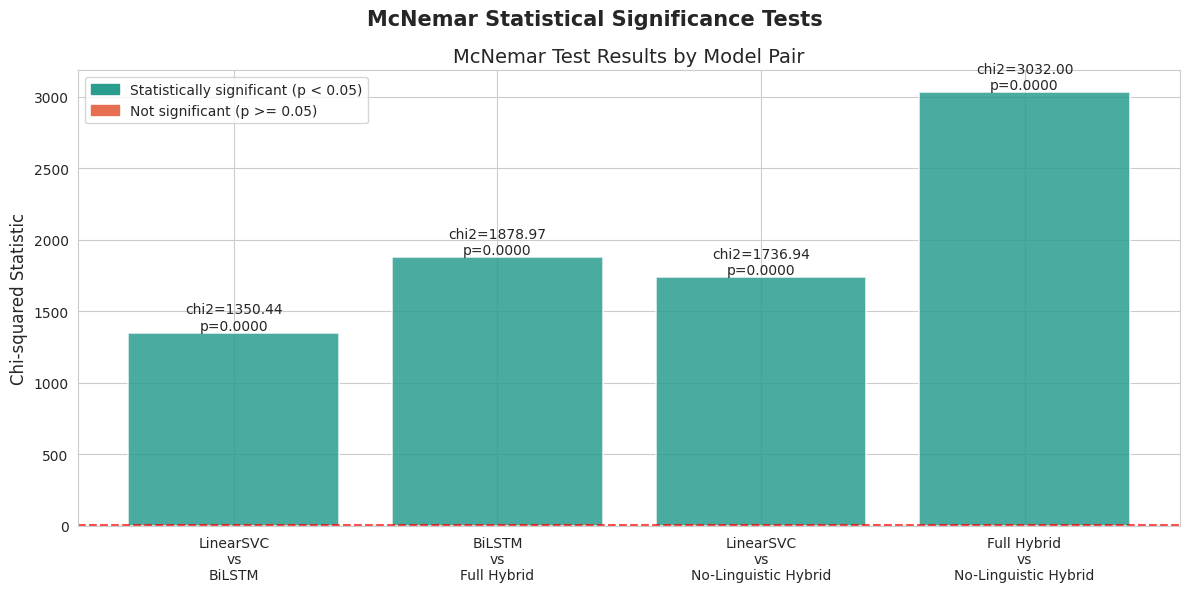

Saved: outputs/figures/ablation/29_mcnemar_results.png


In [12]:
fig, ax = plt.subplots(figsize=(12, 6))

pair_labels = [
    f"{r['model_a']}\nvs\n{r['model_b']}"
    for r in results_list
]
chi2_values = [r['chi2'] for r in results_list]
p_values    = [r['p_value'] for r in results_list]

# Green if significant, red if not
bar_colors = [
    '#2A9D8F' if r['significant'] else '#E76F51'
    for r in results_list
]

bars = ax.bar(pair_labels, chi2_values,
              color=bar_colors, alpha=0.85,
              edgecolor='white', linewidth=1.2)

# Value and p-value labels on bars
for bar, chi2, p in zip(bars, chi2_values, p_values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'chi2={chi2:.2f}\np={p:.4f}',
            ha='center', va='bottom', fontsize=10)

# Significance threshold line at chi2=3.84
# This corresponds to p=0.05 with 1 degree of freedom
ax.axhline(y=3.84, color='red', linestyle='--',
           linewidth=1.5, alpha=0.7,
           label='Significance threshold (chi2=3.84, p=0.05)')

ax.set_ylabel('Chi-squared Statistic', fontsize=12)
ax.set_title('McNemar Test Results by Model Pair',
             fontsize=14)

legend_handles = [
    mpatches.Patch(color='#2A9D8F',
                   label='Statistically significant (p < 0.05)'),
    mpatches.Patch(color='#E76F51',
                   label='Not significant (p >= 0.05)'),
]
ax.legend(handles=legend_handles, fontsize=10)

fig.suptitle('McNemar Statistical Significance Tests',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_DIR, '29_mcnemar_results.png'),
    dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/figures/ablation/29_mcnemar_results.png")

### Plot 30 -- Disagreement Heatmap

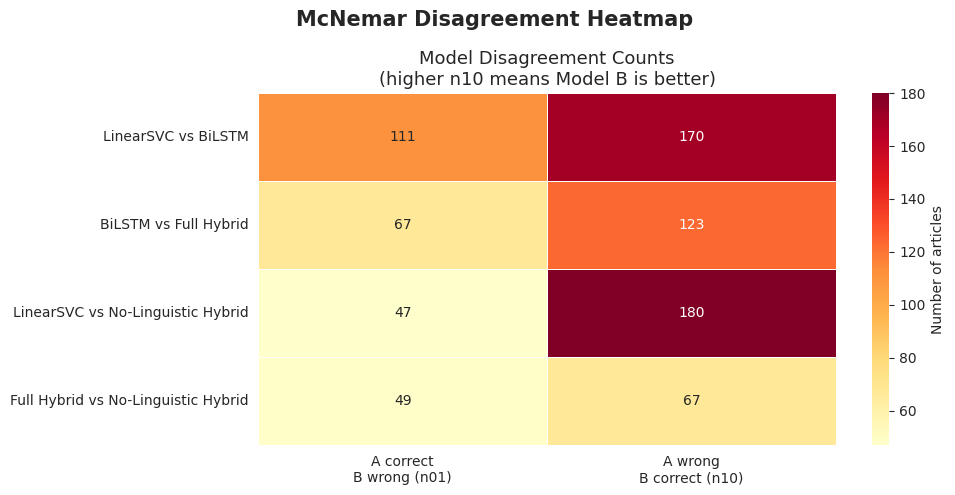

Saved: outputs/figures/ablation/30_disagreement_heatmap.png


In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

# Build heatmap data showing n01 and n10 per pair
pair_names = [
    f"{r['model_a']} vs {r['model_b']}"
    for r in results_list
]
heatmap_data = np.array([
    [r['n01'], r['n10']]
    for r in results_list
])
heatmap_df = pd.DataFrame(
    heatmap_data,
    index=pair_names,
    columns=['A correct\nB wrong (n01)',
             'A wrong\nB correct (n10)']
)

sns.heatmap(
    heatmap_df,
    annot=True, fmt='d',
    cmap='YlOrRd',
    ax=ax,
    linewidths=0.5,
    cbar_kws={'label': 'Number of articles'}
)

ax.set_title(
    'Model Disagreement Counts\n'
    '(higher n10 means Model B is better)',
    fontsize=13)

fig.suptitle('McNemar Disagreement Heatmap',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_DIR, '30_disagreement_heatmap.png'),
    dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/figures/ablation/30_disagreement_heatmap.png")

## Section 10 -- Final Conclusions

In [14]:
print_section("SIGNIFICANCE TEST CONCLUSIONS")

for r in results_list:
    pair = f"{r['model_a']} vs {r['model_b']}"
    print(f"\n{pair}:")
    if r['significant']:
        better = r['model_b'] if r['n10'] > r['n01'] \
                 else r['model_a']
        print(f"  SIGNIFICANT (chi2={r['chi2']:.2f}, "
              f"p={r['p_value']:.6f})")
        print(f"  {better} is significantly better.")
        print(f"  {r['n10']:,} articles where "
              f"{r['model_b']} correct, "
              f"{r['model_a']} wrong.")
        print(f"  {r['n01']:,} articles where "
              f"{r['model_a']} correct, "
              f"{r['model_b']} wrong.")
    else:
        print(f"  NOT SIGNIFICANT (chi2={r['chi2']:.2f}, "
              f"p={r['p_value']:.6f})")
        print(f"  No statistically significant difference.")

print()
print("=" * 60)
print("OVERALL CONCLUSION")
print("=" * 60)
all_significant = all(r['significant'] for r in results_list)
if all_significant:
    print("All three comparisons are statistically")
    print("significant at alpha=0.05.")
    print("The observed performance improvements are")
    print("not due to random chance.")
else:
    n_sig = sum(r['significant'] for r in results_list)
    print(f"{n_sig} of 3 comparisons are statistically")
    print("significant at alpha=0.05.")

SIGNIFICANCE TEST CONCLUSIONS

LinearSVC vs BiLSTM:
  SIGNIFICANT (chi2=1350.44, p=0.000000)
  BiLSTM is significantly better.
  170 articles where BiLSTM correct, LinearSVC wrong.
  111 articles where LinearSVC correct, BiLSTM wrong.

BiLSTM vs Full Hybrid:
  SIGNIFICANT (chi2=1878.97, p=0.000000)
  Full Hybrid is significantly better.
  123 articles where Full Hybrid correct, BiLSTM wrong.
  67 articles where BiLSTM correct, Full Hybrid wrong.

LinearSVC vs No-Linguistic Hybrid:
  SIGNIFICANT (chi2=1736.94, p=0.000000)
  No-Linguistic Hybrid is significantly better.
  180 articles where No-Linguistic Hybrid correct, LinearSVC wrong.
  47 articles where LinearSVC correct, No-Linguistic Hybrid wrong.

Full Hybrid vs No-Linguistic Hybrid:
  SIGNIFICANT (chi2=3032.00, p=0.000000)
  No-Linguistic Hybrid is significantly better.
  67 articles where No-Linguistic Hybrid correct, Full Hybrid wrong.
  49 articles where Full Hybrid correct, No-Linguistic Hybrid wrong.

OVERALL CONCLUSION
All t

## Next Steps

With statistical significance confirmed, all computational
work is complete. The remaining tasks are:

1. Streamlit demo application (app/ folder)
   - Live prediction interface
   - Model comparison dashboard
   - Feature visualization

2. Written report (report/ folder)
   - 8-12 pages following assignment structure
   - All plots and tables generated across notebooks
   - Literature review citing all 9+ papers

3. Presentation slides
   - 10-15 minute poster session
   - Key findings from all notebooks